In [1]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\util'))
sys.path.append(os.path.join(now_dir, r'models\spindle_3'))

d:\mynew\demo_all


### 新增个别参数50seeds,存在Jet_Jer_specific(但是已经把spindle_3里面的噪声关掉，所以无法运行此50seeds，只有各群体的初始值不同;所用的scale2是0.0013，是偏大的)

In [ ]:
import numpy as np
import runModels as rm
import defaultParameters as dp
import os

# ========== 参数设置 ==========
n_runs = 50
c2tsc = 0.8
scale2 = 0.0013

# ========== 从 logspace 提取精确值 ==========
Jet_max = 1.98 * 30   # 59.4
Jer_max = 3.24 * 30   # 97.2

# 原始的 logspace 参数
Jet_list = np.logspace(np.log10(0.1), np.log10(Jet_max), 8)
Jer_list = np.logspace(np.log10(0.1), np.log10(Jer_max), 10)

print("="*60)
print("Jet_list (8 个值):")
for i, v in enumerate(Jet_list):
    print(f"  {i}: {v:.6f}")

print("\nJer_list (10 个值):")
for i, v in enumerate(Jer_list):
    print(f"  {i}: {v:.6f}")

# ========== 提取目标值 ==========
# Jet=0.1 就是 Jet_list[0]
target_Jet_1 = Jet_list[0]  # 0.1

# Jet=18.4297 在列表中找最接近的
target_Jet_2 = None
for v in Jet_list:
    if abs(v - 18.4297) < 0.01:
        target_Jet_2 = v
        break
if target_Jet_2 is None:
    # 如果没找到，取最接近的
    target_Jet_2 = Jet_list[np.argmin(np.abs(Jet_list - 18.4297))]

# Jer=0.2273 在列表中找最接近的
target_Jer = None
for v in Jer_list:
    if abs(v - 0.2273) < 0.01:
        target_Jer = v
        break
if target_Jer is None:
    target_Jer = Jer_list[np.argmin(np.abs(Jer_list - 0.2273))]

print("\n" + "="*60)
print("提取的目标值:")
print(f"  Jet_1 (0.1): {target_Jet_1:.6f}")
print(f"  Jet_2 (≈18.4297): {target_Jet_2:.6f}")
print(f"  Jer (≈0.2273): {target_Jer:.6f}")

# ========== 定义两组参数 ==========
param_groups = [
    {
        'name': f'Jet_{target_Jet_1:.4f}_Jer_{target_Jer:.4f}',
        'Jet': target_Jet_1,
        'Jer': target_Jer,
    },
    {
        'name': f'Jet_{target_Jet_2:.4f}_Jer_{target_Jer:.4f}',
        'Jet': target_Jet_2,
        'Jer': target_Jer,
    },
]

print("\n" + "="*60)
print("运行参数:")
for group in param_groups:
    print(f"  {group['name']}: Jet={group['Jet']:.6f}, Jer={group['Jer']:.6f}, seeds={n_runs}")

# ========== 创建保存目录 ==========
DATA_DIR = "data/raw_data_explore_Jet_Jer_specific"
os.makedirs(DATA_DIR, exist_ok=True)

# ========== 统计已完成文件 ==========
existing_files = set()
for f in os.listdir(DATA_DIR):
    if f.endswith(".npy"):
        existing_files.add(f)
print(f"\n已存在 {len(existing_files)} 个文件")

# ========== 运行任务 ==========
total_tasks = len(param_groups) * n_runs
completed = 0
skipped = 0

for group in param_groups:
    Jet_val = group['Jet']
    Jer_val = group['Jer']
    group_name = group['name']
    
    print(f"\n运行: {group_name}")
    
    for seed in range(1, n_runs + 1):
        filename = f"c2tsc_{c2tsc:.4f}_scale2_{scale2:.6f}_Jet_{Jet_val:.6f}_Jer_{Jer_val:.6f}_seed_{seed}.npy"
        save_path = os.path.join(DATA_DIR, filename)
        
        if filename in existing_files:
            print(f"  跳过已存在: seed={seed}")
            skipped += 1
            continue
        
        params = dp.loadDefaultParams(seed)
        params["c2tsc"] = c2tsc
        params["scale2"] = scale2
        params["Jet"] = Jet_val
        params["Jer"] = Jer_val
        
        try:
            t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
        except Exception as e:
            print(f"  失败: seed={seed}, 错误: {e}")
            continue
        
        np.save(save_path, {
            "t": t, "V_e": V_e, "V_i": V_i, 
            "Q_e": Q_e, "Q_i": Q_i, 
            "V_t": V_t, "V_r": V_r, 
            "Q_t": Q_t, "Q_r": Q_r,
            "c2tsc": c2tsc,
            "scale2": scale2,
            "Jet": Jet_val,
            "Jer": Jer_val,
            "seed": seed
        })
        
        completed += 1
        if completed % 10 == 0:
            print(f"  进度: {completed}/{total_tasks}")

print("\n" + "="*60)
print("完成统计")
print("="*60)
print(f"总任务数: {total_tasks}")
print(f"新运行: {completed}")
print(f"跳过已存在: {skipped}")
print(f"数据保存在: {DATA_DIR}")

# ========== 显示生成的文件 ==========
print("\n生成的文件:")
for group in param_groups:
    Jet_val = group['Jet']
    Jer_val = group['Jer']
    count = 0
    for f in os.listdir(DATA_DIR):
        if f.endswith(".npy") and f"Jet_{Jet_val:.6f}" in f and f"Jer_{Jer_val:.6f}" in f:
            count += 1
    print(f"  {group['name']}: {count} 个文件")

### 6.22汇报时的参数全探索

In [2]:
import numpy as np
import runModels as rm
import defaultParameters as dp
import os

# ========== 参数设置 ==========
n_runs = 10              # 每个参数组合运行的次数
c2tsc = 0.8              # 固定 c2tsc
scale2 = 0.0013          # 固定 scale2


Jet_max = 1.98 * 75   # 148.5
Jer_max = 3.24 * 50   # 162

# 对数间隔：小值变化更精细
Jet_list = np.logspace(np.log10(0.1), np.log10(Jet_max), 8)  # 从 0.1 开始，避免 0
#Jet_list = np.insert(Jet_list, 0, 0)  # 如果想包含 0，手动加上

Jer_list = np.logspace(np.log10(0.1), np.log10(Jer_max), 10)
#Jer_list = np.insert(Jer_list, 0, 0)

print(f"Jet 范围: {Jet_list}")
print(f"Jer 范围: {Jer_list}")
print(f"总参数组合数: {len(Jet_list) * len(Jer_list)}")
print(f"总运行次数: {len(Jet_list) * len(Jer_list) * n_runs}")



Jet 范围: [1.00000000e-01 2.83859726e-01 8.05763440e-01 2.28723789e+00
 6.49254721e+00 1.84297267e+01 5.23145718e+01 1.48500000e+02]
Jer 范围: [1.00000000e-01 2.27306984e-01 5.16684649e-01 1.17446029e+00
 2.66963027e+00 6.06825604e+00 1.37935698e+01 3.13537474e+01
 7.12692576e+01 1.62000000e+02]
总参数组合数: 80
总运行次数: 800


In [5]:

# 创建保存目录
DATA_DIR = "data/raw_data_explore_Jet_Jer"
os.makedirs(DATA_DIR, exist_ok=True)

# 统计已完成文件，支持断点续跑
existing_files = set()
for f in os.listdir(DATA_DIR):
    if f.endswith(".npy"):
        existing_files.add(f)
print(f"已存在 {len(existing_files)} 个文件，将跳过它们")

total_tasks = len(Jet_list) * len(Jer_list) * n_runs
completed = 0
skipped = 0

for Jet_val in Jet_list:
    for Jer_val in Jer_list:
        for seed in range(1, n_runs + 1):
            # 生成文件名
            filename = f"c2tsc_{c2tsc:.4f}_scale2_{scale2:.4f}_Jet_{Jet_val:.4f}_Jer_{Jer_val:.4f}_seed_{seed}.npy"
            save_path = os.path.join(DATA_DIR, filename)
            
            # 如果文件已存在，跳过
            if filename in existing_files:
                skipped += 1
                print(f"跳过: {filename}")
                continue
            
            # 加载默认参数并修改
            params = dp.loadDefaultParams(seed)
            params["c2tsc"] = c2tsc
            params["scale2"] = scale2
            params["Jet"] = Jet_val
            params["Jer"] = Jer_val
            
            # 运行模型
            try:
                t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
            except Exception as e:
                print(f"模型运行失败: {filename}, 错误: {e}")
                continue
            
            # 保存 raw 信号
            np.save(save_path, {
                "t": t, "V_e": V_e, "V_i": V_i, 
                "Q_e": Q_e, "Q_i": Q_i, 
                "V_t": V_t, "V_r": V_r, 
                "Q_t": Q_t, "Q_r": Q_r,
                "c2tsc": c2tsc,
                "scale2": scale2,
                "Jet": Jet_val,
                "Jer": Jer_val,
                "seed": seed
            })
            completed += 1
            print(f"Saved: Jet={Jet_val:.4f}, Jer={Jer_val:.4f}, seed={seed} (已完成 {completed})")

print(f"\n完成！新运行: {completed}, 跳过: {skipped}")
print(f"数据保存在: {DATA_DIR}")

已存在 0 个文件，将跳过它们
Saved: Jet=0.1000, Jer=0.1000, seed=1 (已完成 1)
Saved: Jet=0.1000, Jer=0.1000, seed=2 (已完成 2)
Saved: Jet=0.1000, Jer=0.1000, seed=3 (已完成 3)
Saved: Jet=0.1000, Jer=0.1000, seed=4 (已完成 4)
Saved: Jet=0.1000, Jer=0.1000, seed=5 (已完成 5)
Saved: Jet=0.1000, Jer=0.1000, seed=6 (已完成 6)
Saved: Jet=0.1000, Jer=0.1000, seed=7 (已完成 7)
Saved: Jet=0.1000, Jer=0.1000, seed=8 (已完成 8)
Saved: Jet=0.1000, Jer=0.1000, seed=9 (已完成 9)
Saved: Jet=0.1000, Jer=0.1000, seed=10 (已完成 10)
Saved: Jet=0.1000, Jer=0.2273, seed=1 (已完成 11)
Saved: Jet=0.1000, Jer=0.2273, seed=2 (已完成 12)
Saved: Jet=0.1000, Jer=0.2273, seed=3 (已完成 13)
Saved: Jet=0.1000, Jer=0.2273, seed=4 (已完成 14)
Saved: Jet=0.1000, Jer=0.2273, seed=5 (已完成 15)
Saved: Jet=0.1000, Jer=0.2273, seed=6 (已完成 16)
Saved: Jet=0.1000, Jer=0.2273, seed=7 (已完成 17)
Saved: Jet=0.1000, Jer=0.2273, seed=8 (已完成 18)
Saved: Jet=0.1000, Jer=0.2273, seed=9 (已完成 19)
Saved: Jet=0.1000, Jer=0.2273, seed=10 (已完成 20)
Saved: Jet=0.1000, Jer=0.5167, seed=1 (已完成 21)
Save

In [6]:
import requests
ret = requests.get('https://api.day.app/TUiWwsBpShFTPWk8JWWLxW/program/thalamusfor20251128_11:10isdone')


In [7]:
import numpy as np
import pandas as pd
import yasa
import glob
from scipy.signal import hilbert
import xarray as xr
from neurolib.utils.signal import Signal, RatesSignal
import os

# ========== 只需要改这几行 ==========
DATA_FOLDER = "Jet_Jer"           # 数据文件夹名
PARAM1_NAME = "Jet"               # 第一个参数名
PARAM2_NAME = "Jer"               # 第二个参数名
PARAM1_RANGE = (0, 148.5)         # Jet 范围 (min, max)
PARAM2_RANGE = (0, 162)           # Jer 范围 (min, max)
# =================================

# 自动生成路径和配置
RAW_DATA_DIR = f"data/raw_data_explore_{DATA_FOLDER}"
OUTPUT_PREFIX = f"spindles_{DATA_FOLDER}"

def get_phase_and_envelope(signal, filter_args, pad=None):
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(how_much=pad, in_seconds=True, padding_type="reflect", side="both")
    phase.filter(**filter_args)
    filtered = phase.data.values.copy()
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    analytic = hilbert(filtered)
    envelope = np.abs(analytic)
    return phase.data.values, filtered, envelope

def process_spindles(sp, spindle_type, params, t_mid, sf, t_min, t_max, envelope, slow_phase_masked):
    results = []
    if sp is None:
        return results
    df = sp.summary()
    for _, row in df.iterrows():
        start_time = row["Start"]
        peak_time = row["Peak"]
        end_time = row["End"]
        start_idx_sample = int(start_time * sf)
        peak_idx_sample = int(peak_time * sf)
        end_idx_sample = int(end_time * sf)
        if not (t_min <= start_idx_sample <= t_max and t_min <= end_idx_sample <= t_max):
            continue
        start_idx = np.argmin(np.abs(t_mid - start_idx_sample))
        peak_idx = np.argmin(np.abs(t_mid - peak_idx_sample))
        end_idx = np.argmin(np.abs(t_mid - end_idx_sample))
        phase_start = slow_phase_masked[start_idx]
        phase_peak = slow_phase_masked[peak_idx]
        phase_end = slow_phase_masked[end_idx]
        results.append({
            **params,
            "type": spindle_type,
            "start": start_time,
            "peak_time": peak_time,
            "end": end_time,
            "duration": row["Duration"],
            "frequency": row["Frequency"],
            "amplitude": row["Amplitude"],
            "phase_at_start": phase_start,
            "phase_at_peak": phase_peak,
            "phase_at_end": phase_end,
            "envelope_at_start": envelope[start_idx],
            "envelope_at_peak": envelope[peak_idx],
            "envelope_at_end": envelope[end_idx],
            "masked": np.isnan(phase_peak),
        })
    return results

# ========== 主程序 ==========
sf = 10000
remove_edges_samples = 20000
SW = {"low_freq": None, "high_freq": 3.0}
amplitude_threshold = 2

file_list = glob.glob(os.path.join(RAW_DATA_DIR, "*.npy"))
print(f"找到 {len(file_list)} 个文件")
print(f"限定 {PARAM1_NAME} 范围: {PARAM1_RANGE}")
print(f"限定 {PARAM2_NAME} 范围: {PARAM2_RANGE}")
print(f"输出前缀: {OUTPUT_PREFIX}")

all_spindles = []

for file_path in file_list:
    file_path = file_path.replace("\\", "/")
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    
    # 新文件名格式: c2tsc_{val}_scale2_{val}_Jet_{val}_Jer_{val}_seed_{val}
    # parts = ['c2tsc', '0.8000', 'scale2', '0.0013', 'Jet', '1.9800', 'Jer', '3.2400', 'seed', '1']
    c2tsc = float(parts[1])
    scale2 = float(parts[3])
    
    # 找到 Jet 和 Jer 的位置（因为参数名是固定的）
    Jet_idx = parts.index(PARAM1_NAME) + 1 if PARAM1_NAME in parts else -1
    Jer_idx = parts.index(PARAM2_NAME) + 1 if PARAM2_NAME in parts else -1
    seed_idx = parts.index('seed') + 1 if 'seed' in parts else -1
    
    if Jet_idx == -1 or Jer_idx == -1 or seed_idx == -1:
        print(f"  警告：无法解析文件名 {filename}，跳过")
        continue
    
    Jet_val = float(parts[Jet_idx])
    Jer_val = float(parts[Jer_idx])
    seed = int(parts[seed_idx])
    
    # 过滤参数范围
    if not (PARAM1_RANGE[0] <= Jet_val <= PARAM1_RANGE[1]):
        continue
    if not (PARAM2_RANGE[0] <= Jer_val <= PARAM2_RANGE[1]):
        continue
    
    print(f"Processing: {PARAM1_NAME}={Jet_val:.4f}, {PARAM2_NAME}={Jer_val:.4f}, seed={seed}")
    
    data = np.load(file_path, allow_pickle=True).item()
    t = data["t"]
    V_t = data["V_t"]
    V_e = data["V_e"]
    
    t_min = remove_edges_samples
    t_max = t[-1] - remove_edges_samples
    
    mask = (t >= t_min) & (t <= t_max)
    t_mid = t[mask]
    V_e_mid = V_e[mask]
    
    if len(t_mid) == 0:
        print(f"  警告：没有有效数据，跳过")
        continue
    
    results_df = pd.DataFrame({"ALN": V_e_mid}, index=t_mid / sf)
    results_df.index.name = "time"
    aln_xr = xr.DataArray(results_df["ALN"])
    aln_sig = RatesSignal(aln_xr)
    
    slow_phase, V_slow, envelope = get_phase_and_envelope(aln_sig, filter_args=SW, pad=0.0)
    
    mask_amplitude = envelope > amplitude_threshold
    slow_phase_masked = slow_phase.copy()
    slow_phase_masked[~mask_amplitude] = np.nan
    
    params = {
        "c2tsc": c2tsc, 
        "scale2": scale2, 
        PARAM1_NAME: Jet_val, 
        PARAM2_NAME: Jer_val, 
        "seed": seed
    }
    
    sp_fast = yasa.spindles_detect(V_t, sf, freq_sp=(12,16), duration=(0.3,2))
    all_spindles.extend(process_spindles(sp_fast, "fast", params, t_mid, sf, t_min, t_max, envelope, slow_phase_masked))
    
    sp_slow = yasa.spindles_detect(V_t, sf, freq_sp=(8,12), duration=(0.3,2))
    all_spindles.extend(process_spindles(sp_slow, "slow", params, t_mid, sf, t_min, t_max, envelope, slow_phase_masked))
    
    print(f"  完成")

os.makedirs("data/analysis_data", exist_ok=True)
result_df = pd.DataFrame(all_spindles)
result_df.to_csv(f"data/analysis_data/{OUTPUT_PREFIX}_explore_limited.csv", index=False)

result_df_valid = result_df[~result_df['masked']].copy()
result_df_valid.to_csv(f"data/analysis_data/{OUTPUT_PREFIX}_explore_valid_limited.csv", index=False)

print(f"\n总共检测到 {len(result_df)} 个纺锤波")
print(f"相位有效: {len(result_df_valid)} 个")

找到 800 个文件
限定 Jet 范围: (0, 148.5)
限定 Jer 范围: (0, 162)
输出前缀: spindles_Jet_Jer
Processing: Jet=0.1000, Jer=0.1000, seed=1
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



d:\anaconda\envs\neurolib_old\lib\site-packages\outdated\utils.py:18: OutdatedPackageWarning: The package yasa is out of date. Your version is 0.6.3, the latest is 0.7.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBacke

  完成
Processing: Jet=0.1000, Jer=0.1000, seed=10
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成
Processing: Jet=0.1000, Jer=0.1000, seed=2
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



...

  完成
Processing: Jet=6.4925, Jer=71.2693, seed=9
Setting up low-pass filter at 3 Hz


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished



FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成

总共检测到 8085 个纺锤波
相位有效: 6907 个


总纺锤波数: 6907
Jet 范围: 0.10 ~ 148.50
Jer 范围: 0.10 ~ 162.00

统计结果列名:
['Jet', 'Jer', 'type', 'mean_count', 'std_count', 'mean_duration', 'std_duration', 'mean_total_duration', 'std_total_duration']

Jet 采样点: 8
Jer 采样点: 10


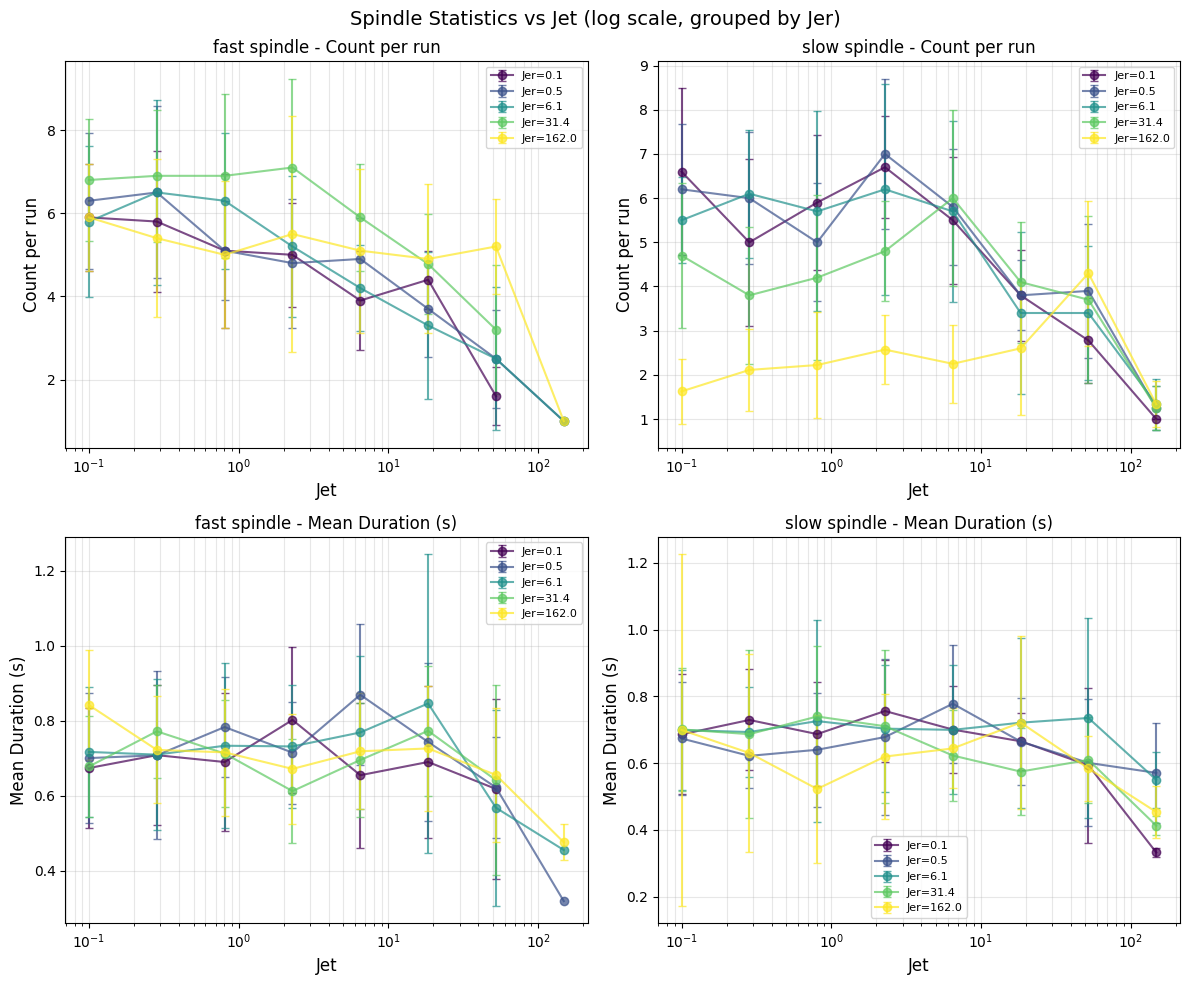

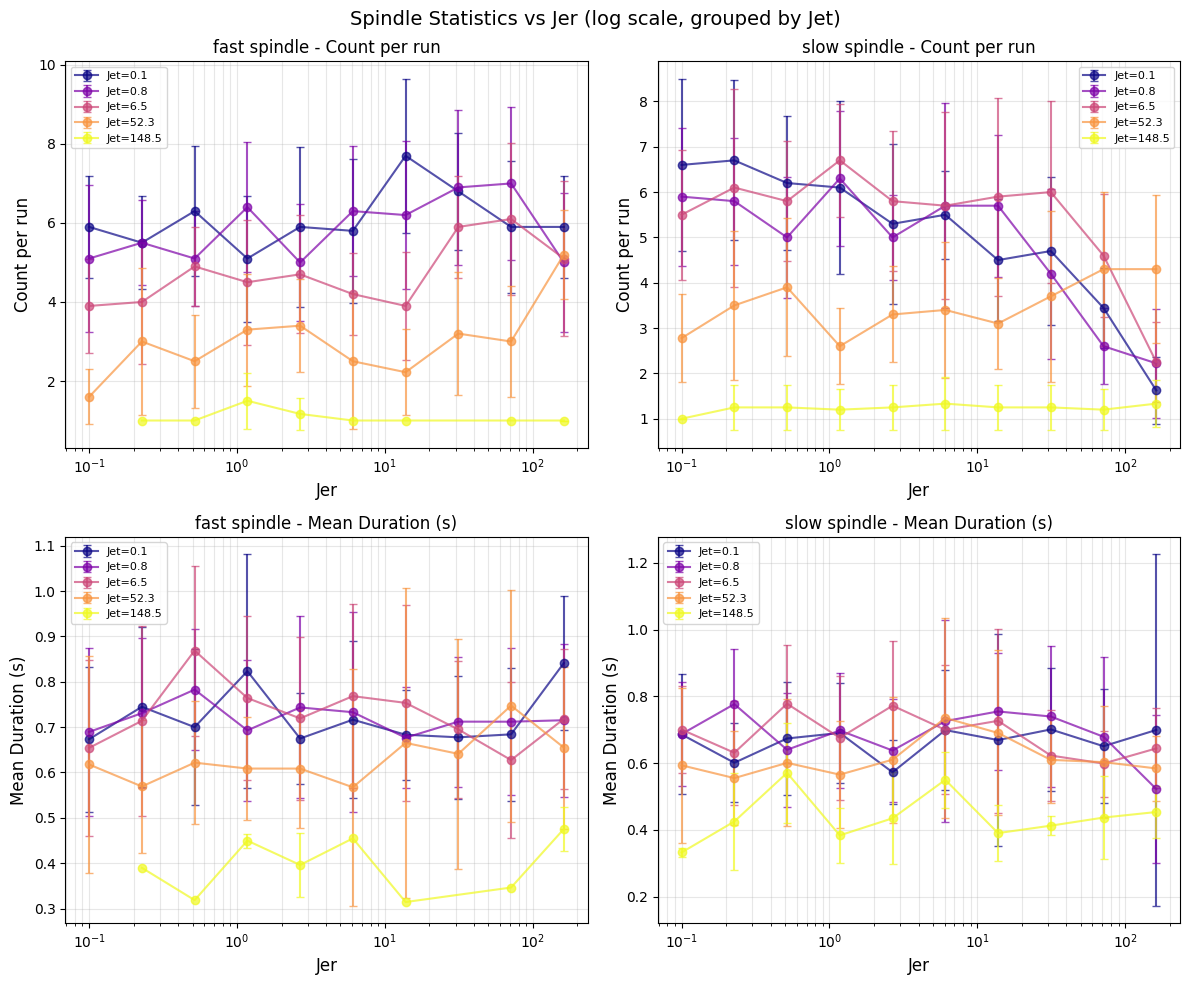

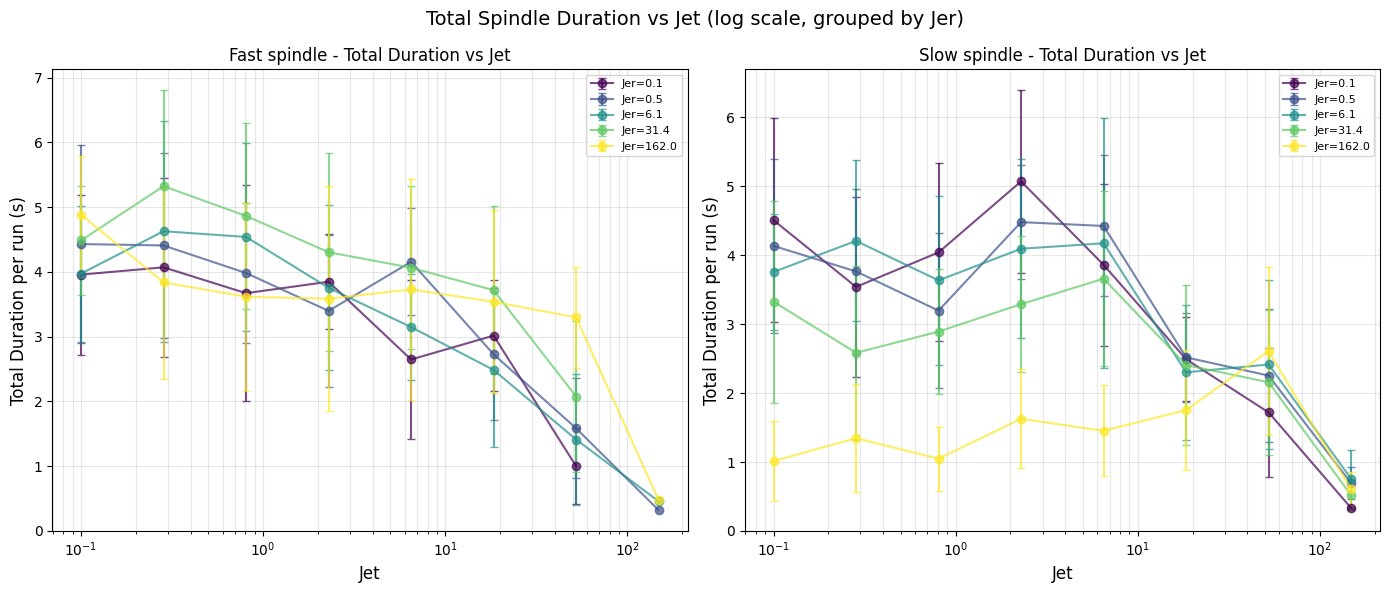

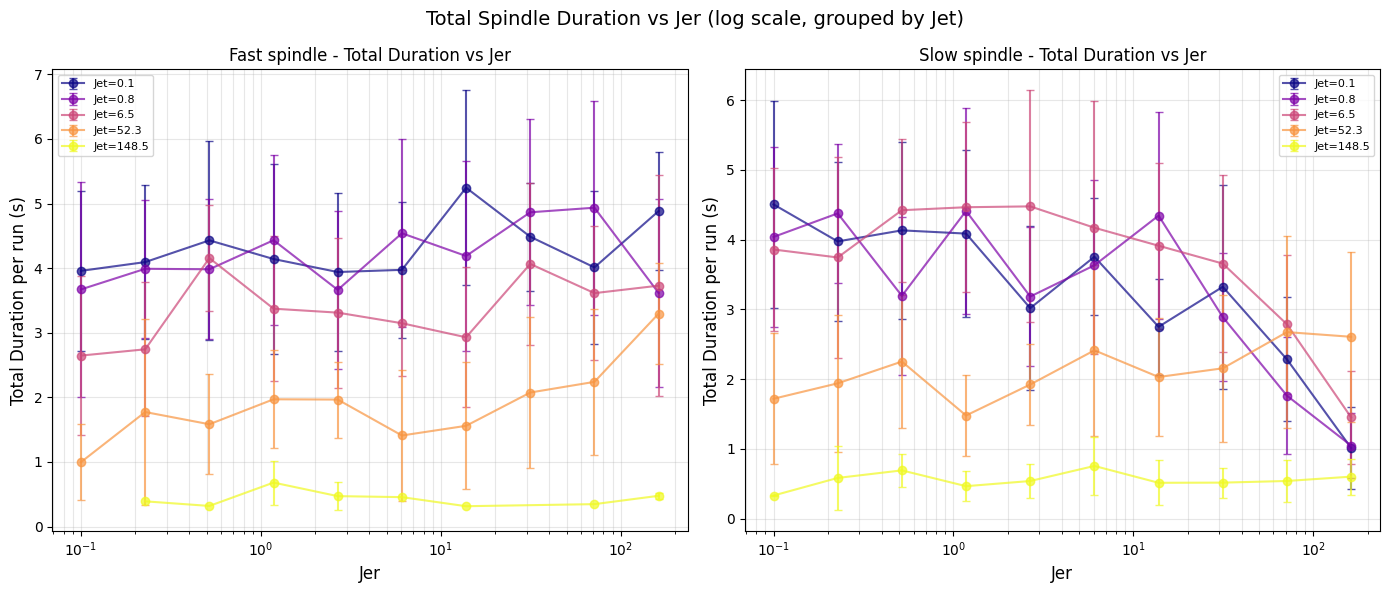

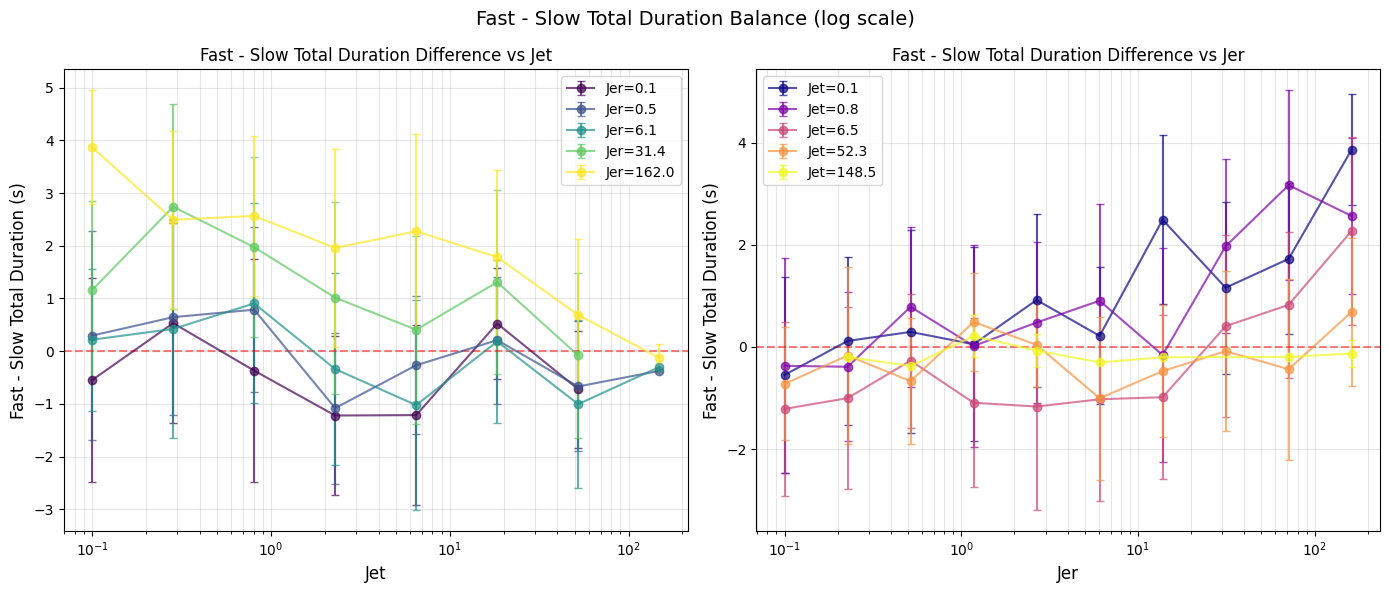


统计摘要

FAST 纺锤波:
  数量最多: Jet=0.1, Jer=13.8, count=7.7
  数量最少: Jet=148.5, Jer=0.2, count=1.0
  时长最长: Jet=6.5, Jer=0.5, duration=0.869s
  时长最短: Jet=148.5, Jer=13.8, duration=0.314s
  总时长最大: Jet=0.3, Jer=31.4, total=5.32s
  总时长最小: Jet=148.5, Jer=13.8, total=0.31s

SLOW 纺锤波:
  数量最多: Jet=2.3, Jer=2.7, count=7.6
  数量最少: Jet=148.5, Jer=0.1, count=1.0
  时长最长: Jet=0.3, Jer=13.8, duration=0.892s
  时长最短: Jet=148.5, Jer=0.1, duration=0.332s
  总时长最大: Jet=2.3, Jer=0.1, total=5.07s
  总时长最小: Jet=148.5, Jer=0.1, total=0.33s

相关性分析（log 变换后）

FAST 纺锤波:
  log10(Jet) vs 数量: r=-0.850, p=0.0000
  log10(Jet) vs 时长: r=-0.594, p=0.0000
  log10(Jet) vs 总时长: r=-0.862, p=0.0000
  log10(Jer) vs 数量: r=0.154, p=0.1781
  log10(Jer) vs 时长: r=-0.001, p=0.9947
  log10(Jer) vs 总时长: r=0.130, p=0.2564

SLOW 纺锤波:
  log10(Jet) vs 数量: r=-0.552, p=0.0000
  log10(Jet) vs 时长: r=-0.576, p=0.0000
  log10(Jet) vs 总时长: r=-0.573, p=0.0000
  log10(Jer) vs 数量: r=-0.378, p=0.0005
  log10(Jer) vs 时长: r=-0.004, p=0.9694
  log10(Jer) vs 总时长

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ========== 读取数据 ==========
df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_explore_valid_limited.csv")

# ========== 数据筛选 ==========
if 'masked' in df.columns:
    df = df[~df['masked']].copy()

print(f"总纺锤波数: {len(df)}")
print(f"Jet 范围: {df['Jet'].min():.2f} ~ {df['Jet'].max():.2f}")
print(f"Jer 范围: {df['Jer'].min():.2f} ~ {df['Jer'].max():.2f}")

# ========== 按 Jet, Jer, seed, type 分组统计 ==========
seed_stats = df.groupby(['Jet', 'Jer', 'seed', 'type']).agg(
    count=('duration', 'size'),
    mean_duration=('duration', 'mean'),
    total_duration=('duration', 'sum'),
).reset_index()

# 再按 Jet, Jer, type 汇总
summary_stats = seed_stats.groupby(['Jet', 'Jer', 'type']).agg(
    mean_count=('count', 'mean'),
    std_count=('count', 'std'),
    mean_duration=('mean_duration', 'mean'),
    std_duration=('mean_duration', 'std'),
    mean_total_duration=('total_duration', 'mean'),
    std_total_duration=('total_duration', 'std'),
).reset_index()

print("\n统计结果列名:")
print(summary_stats.columns.tolist())

# ========== 获取参数值（已经是对数间隔）==========
Jet_values = sorted(df['Jet'].unique())
Jer_values = sorted(df['Jer'].unique())
print(f"\nJet 采样点: {len(Jet_values)}")
print(f"Jer 采样点: {len(Jer_values)}")

# ========== 1. 折线图：Jet 的影响（固定不同的 Jer）==========
if len(Jer_values) > 5:
    Jer_representative = [Jer_values[0], Jer_values[len(Jer_values)//4], 
                          Jer_values[len(Jer_values)//2], Jer_values[3*len(Jer_values)//4], 
                          Jer_values[-1]]
else:
    Jer_representative = Jer_values

colors = plt.cm.viridis(np.linspace(0, 1, len(Jer_representative)))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# 指标1：数量
metric = 'mean_count'
std_metric = 'std_count'
ylabel = 'Count per run'
for col_idx, spindle_type in enumerate(['fast', 'slow']):
    ax = axes[col_idx]
    for i, Jer_val in enumerate(Jer_representative):
        subset = summary_stats[(summary_stats['type'] == spindle_type) & 
                               (np.abs(summary_stats['Jer'] - Jer_val) < 1e-6)]
        if len(subset) > 0:
            subset_sorted = subset.sort_values('Jet')
            ax.errorbar(subset_sorted['Jet'], subset_sorted[metric], 
                       yerr=subset_sorted[std_metric],
                       fmt='o-', capsize=3, color=colors[i], 
                       label=f'Jer={Jer_val:.1f}', alpha=0.7)
    ax.set_xlabel('Jet', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f'{spindle_type} spindle - {ylabel}', fontsize=12)
    ax.set_xscale('log')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, which='both')

# 指标2：平均时长
metric = 'mean_duration'
std_metric = 'std_duration'
ylabel = 'Mean Duration (s)'
for col_idx, spindle_type in enumerate(['fast', 'slow']):
    ax = axes[col_idx + 2]
    for i, Jer_val in enumerate(Jer_representative):
        subset = summary_stats[(summary_stats['type'] == spindle_type) & 
                               (np.abs(summary_stats['Jer'] - Jer_val) < 1e-6)]
        if len(subset) > 0:
            subset_sorted = subset.sort_values('Jet')
            ax.errorbar(subset_sorted['Jet'], subset_sorted[metric], 
                       yerr=subset_sorted[std_metric],
                       fmt='o-', capsize=3, color=colors[i], 
                       label=f'Jer={Jer_val:.1f}', alpha=0.7)
    ax.set_xlabel('Jet', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f'{spindle_type} spindle - {ylabel}', fontsize=12)
    ax.set_xscale('log')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, which='both')

plt.suptitle('Spindle Statistics vs Jet (log scale, grouped by Jer)', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 2. 折线图：Jer 的影响（固定不同的 Jet）==========
if len(Jet_values) > 5:
    Jet_representative = [Jet_values[0], Jet_values[len(Jet_values)//4], 
                          Jet_values[len(Jet_values)//2], Jet_values[3*len(Jet_values)//4], 
                          Jet_values[-1]]
else:
    Jet_representative = Jet_values

colors2 = plt.cm.plasma(np.linspace(0, 1, len(Jet_representative)))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# 指标1：数量
metric = 'mean_count'
std_metric = 'std_count'
ylabel = 'Count per run'
for col_idx, spindle_type in enumerate(['fast', 'slow']):
    ax = axes[col_idx]
    for i, Jet_val in enumerate(Jet_representative):
        subset = summary_stats[(summary_stats['type'] == spindle_type) & 
                               (np.abs(summary_stats['Jet'] - Jet_val) < 1e-6)]
        if len(subset) > 0:
            subset_sorted = subset.sort_values('Jer')
            ax.errorbar(subset_sorted['Jer'], subset_sorted[metric], 
                       yerr=subset_sorted[std_metric],
                       fmt='o-', capsize=3, color=colors2[i], 
                       label=f'Jet={Jet_val:.1f}', alpha=0.7)
    ax.set_xlabel('Jer', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f'{spindle_type} spindle - {ylabel}', fontsize=12)
    ax.set_xscale('log')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, which='both')

# 指标2：平均时长
metric = 'mean_duration'
std_metric = 'std_duration'
ylabel = 'Mean Duration (s)'
for col_idx, spindle_type in enumerate(['fast', 'slow']):
    ax = axes[col_idx + 2]
    for i, Jet_val in enumerate(Jet_representative):
        subset = summary_stats[(summary_stats['type'] == spindle_type) & 
                               (np.abs(summary_stats['Jet'] - Jet_val) < 1e-6)]
        if len(subset) > 0:
            subset_sorted = subset.sort_values('Jer')
            ax.errorbar(subset_sorted['Jer'], subset_sorted[metric], 
                       yerr=subset_sorted[std_metric],
                       fmt='o-', capsize=3, color=colors2[i], 
                       label=f'Jet={Jet_val:.1f}', alpha=0.7)
    ax.set_xlabel('Jer', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f'{spindle_type} spindle - {ylabel}', fontsize=12)
    ax.set_xscale('log')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, which='both')

plt.suptitle('Spindle Statistics vs Jer (log scale, grouped by Jet)', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 新增：总时长图 ==========
# 3a: 总时长 vs Jet（固定 Jer）
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左图：快纺锤波总时长 vs Jet
ax = axes[0]
for i, Jer_val in enumerate(Jer_representative):
    subset = summary_stats[(summary_stats['type'] == 'fast') & 
                           (np.abs(summary_stats['Jer'] - Jer_val) < 1e-6)]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jet')
        ax.errorbar(subset_sorted['Jet'], subset_sorted['mean_total_duration'], 
                   yerr=subset_sorted['std_total_duration'],
                   fmt='o-', capsize=3, color=colors[i], 
                   label=f'Jer={Jer_val:.1f}', alpha=0.7)
ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Total Duration per run (s)', fontsize=12)
ax.set_title('Fast spindle - Total Duration vs Jet', fontsize=12)
ax.set_xscale('log')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')

# 右图：慢纺锤波总时长 vs Jet
ax = axes[1]
for i, Jer_val in enumerate(Jer_representative):
    subset = summary_stats[(summary_stats['type'] == 'slow') & 
                           (np.abs(summary_stats['Jer'] - Jer_val) < 1e-6)]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jet')
        ax.errorbar(subset_sorted['Jet'], subset_sorted['mean_total_duration'], 
                   yerr=subset_sorted['std_total_duration'],
                   fmt='o-', capsize=3, color=colors[i], 
                   label=f'Jer={Jer_val:.1f}', alpha=0.7)
ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Total Duration per run (s)', fontsize=12)
ax.set_title('Slow spindle - Total Duration vs Jet', fontsize=12)
ax.set_xscale('log')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')

plt.suptitle('Total Spindle Duration vs Jet (log scale, grouped by Jer)', fontsize=14)
plt.tight_layout()
plt.show()

# 3b: 总时长 vs Jer（固定 Jet）
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左图：快纺锤波总时长 vs Jer
ax = axes[0]
for i, Jet_val in enumerate(Jet_representative):
    subset = summary_stats[(summary_stats['type'] == 'fast') & 
                           (np.abs(summary_stats['Jet'] - Jet_val) < 1e-6)]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jer')
        ax.errorbar(subset_sorted['Jer'], subset_sorted['mean_total_duration'], 
                   yerr=subset_sorted['std_total_duration'],
                   fmt='o-', capsize=3, color=colors2[i], 
                   label=f'Jet={Jet_val:.1f}', alpha=0.7)
ax.set_xlabel('Jer', fontsize=12)
ax.set_ylabel('Total Duration per run (s)', fontsize=12)
ax.set_title('Fast spindle - Total Duration vs Jer', fontsize=12)
ax.set_xscale('log')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')

# 右图：慢纺锤波总时长 vs Jer
ax = axes[1]
for i, Jet_val in enumerate(Jet_representative):
    subset = summary_stats[(summary_stats['type'] == 'slow') & 
                           (np.abs(summary_stats['Jet'] - Jet_val) < 1e-6)]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jer')
        ax.errorbar(subset_sorted['Jer'], subset_sorted['mean_total_duration'], 
                   yerr=subset_sorted['std_total_duration'],
                   fmt='o-', capsize=3, color=colors2[i], 
                   label=f'Jet={Jet_val:.1f}', alpha=0.7)
ax.set_xlabel('Jer', fontsize=12)
ax.set_ylabel('Total Duration per run (s)', fontsize=12)
ax.set_title('Slow spindle - Total Duration vs Jer', fontsize=12)
ax.set_xscale('log')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')

plt.suptitle('Total Spindle Duration vs Jer (log scale, grouped by Jet)', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 快慢对比：总时长差 ==========
fast_total = summary_stats[summary_stats['type'] == 'fast'][['Jet', 'Jer', 'mean_total_duration', 'std_total_duration']]
slow_total = summary_stats[summary_stats['type'] == 'slow'][['Jet', 'Jer', 'mean_total_duration', 'std_total_duration']]
diff_total = pd.merge(fast_total, slow_total, on=['Jet', 'Jer'], suffixes=('_fast', '_slow'))
diff_total['diff_total'] = diff_total['mean_total_duration_fast'] - diff_total['mean_total_duration_slow']
diff_total['diff_total_std'] = np.sqrt(diff_total['std_total_duration_fast']**2 + diff_total['std_total_duration_slow']**2)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 固定 Jer，看 Jet 对总时长差值的影响
ax = axes[0]
for i, Jer_val in enumerate(Jer_representative):
    subset = diff_total[np.abs(diff_total['Jer'] - Jer_val) < 1e-6]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jet')
        ax.errorbar(subset_sorted['Jet'], subset_sorted['diff_total'], 
                   yerr=subset_sorted['diff_total_std'],
                   fmt='o-', capsize=3, color=colors[i], 
                   label=f'Jer={Jer_val:.1f}', alpha=0.7)
ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Fast - Slow Total Duration (s)', fontsize=12)
ax.set_title('Fast - Slow Total Duration Difference vs Jet', fontsize=12)
ax.set_xscale('log')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.3, which='both')

# 固定 Jet，看 Jer 对总时长差值的影响
ax = axes[1]
for i, Jet_val in enumerate(Jet_representative):
    subset = diff_total[np.abs(diff_total['Jet'] - Jet_val) < 1e-6]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jer')
        ax.errorbar(subset_sorted['Jer'], subset_sorted['diff_total'], 
                   yerr=subset_sorted['diff_total_std'],
                   fmt='o-', capsize=3, color=colors2[i], 
                   label=f'Jet={Jet_val:.1f}', alpha=0.7)
ax.set_xlabel('Jer', fontsize=12)
ax.set_ylabel('Fast - Slow Total Duration (s)', fontsize=12)
ax.set_title('Fast - Slow Total Duration Difference vs Jer', fontsize=12)
ax.set_xscale('log')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.3, which='both')

plt.suptitle('Fast - Slow Total Duration Balance (log scale)', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 4. 打印统计摘要 ==========
print("\n" + "="*60)
print("统计摘要")
print("="*60)

for spindle_type in ['fast', 'slow']:
    print(f"\n{spindle_type.upper()} 纺锤波:")
    subset = summary_stats[summary_stats['type'] == spindle_type]
    
    if len(subset) > 0:
        max_count_row = subset.loc[subset['mean_count'].idxmax()]
        min_count_row = subset.loc[subset['mean_count'].idxmin()]
        max_dur_row = subset.loc[subset['mean_duration'].idxmax()]
        min_dur_row = subset.loc[subset['mean_duration'].idxmin()]
        max_total_row = subset.loc[subset['mean_total_duration'].idxmax()]
        min_total_row = subset.loc[subset['mean_total_duration'].idxmin()]
        
        print(f"  数量最多: Jet={max_count_row['Jet']:.1f}, Jer={max_count_row['Jer']:.1f}, count={max_count_row['mean_count']:.1f}")
        print(f"  数量最少: Jet={min_count_row['Jet']:.1f}, Jer={min_count_row['Jer']:.1f}, count={min_count_row['mean_count']:.1f}")
        print(f"  时长最长: Jet={max_dur_row['Jet']:.1f}, Jer={max_dur_row['Jer']:.1f}, duration={max_dur_row['mean_duration']:.3f}s")
        print(f"  时长最短: Jet={min_dur_row['Jet']:.1f}, Jer={min_dur_row['Jer']:.1f}, duration={min_dur_row['mean_duration']:.3f}s")
        print(f"  总时长最大: Jet={max_total_row['Jet']:.1f}, Jer={max_total_row['Jer']:.1f}, total={max_total_row['mean_total_duration']:.2f}s")
        print(f"  总时长最小: Jet={min_total_row['Jet']:.1f}, Jer={min_total_row['Jer']:.1f}, total={min_total_row['mean_total_duration']:.2f}s")

# ========== 5. 相关性分析 ==========
print("\n" + "="*60)
print("相关性分析（log 变换后）")
print("="*60)

for spindle_type in ['fast', 'slow']:
    subset = summary_stats[summary_stats['type'] == spindle_type]
    if len(subset) > 2:
        log_Jet = np.log10(subset['Jet'])
        log_Jer = np.log10(subset['Jer'])
        
        corr_count_jet, p_count_jet = pearsonr(log_Jet, subset['mean_count'])
        corr_dur_jet, p_dur_jet = pearsonr(log_Jet, subset['mean_duration'])
        corr_total_jet, p_total_jet = pearsonr(log_Jet, subset['mean_total_duration'])
        corr_count_jer, p_count_jer = pearsonr(log_Jer, subset['mean_count'])
        corr_dur_jer, p_dur_jer = pearsonr(log_Jer, subset['mean_duration'])
        corr_total_jer, p_total_jer = pearsonr(log_Jer, subset['mean_total_duration'])
        
        print(f"\n{spindle_type.upper()} 纺锤波:")
        print(f"  log10(Jet) vs 数量: r={corr_count_jet:.3f}, p={p_count_jet:.4f}")
        print(f"  log10(Jet) vs 时长: r={corr_dur_jet:.3f}, p={p_dur_jet:.4f}")
        print(f"  log10(Jet) vs 总时长: r={corr_total_jet:.3f}, p={p_total_jet:.4f}")
        print(f"  log10(Jer) vs 数量: r={corr_count_jer:.3f}, p={p_count_jer:.4f}")
        print(f"  log10(Jer) vs 时长: r={corr_dur_jer:.3f}, p={p_dur_jer:.4f}")
        print(f"  log10(Jer) vs 总时长: r={corr_total_jer:.3f}, p={p_total_jer:.4f}")

总纺锤波数: 6907
Jet 范围: 0.10 ~ 148.50
Jer 范围: 0.10 ~ 162.00

统计结果列名:
['Jet', 'Jer', 'type', 'mean_count', 'std_count', 'mean_duration', 'std_duration', 'mean_total_duration', 'std_total_duration']

Jet 采样点: 8
Jer 采样点: 10

固定的 Jer 值: 2.6696 (最接近 2.5)
固定的 Jet 值: 2.2872 (最接近 2.5)


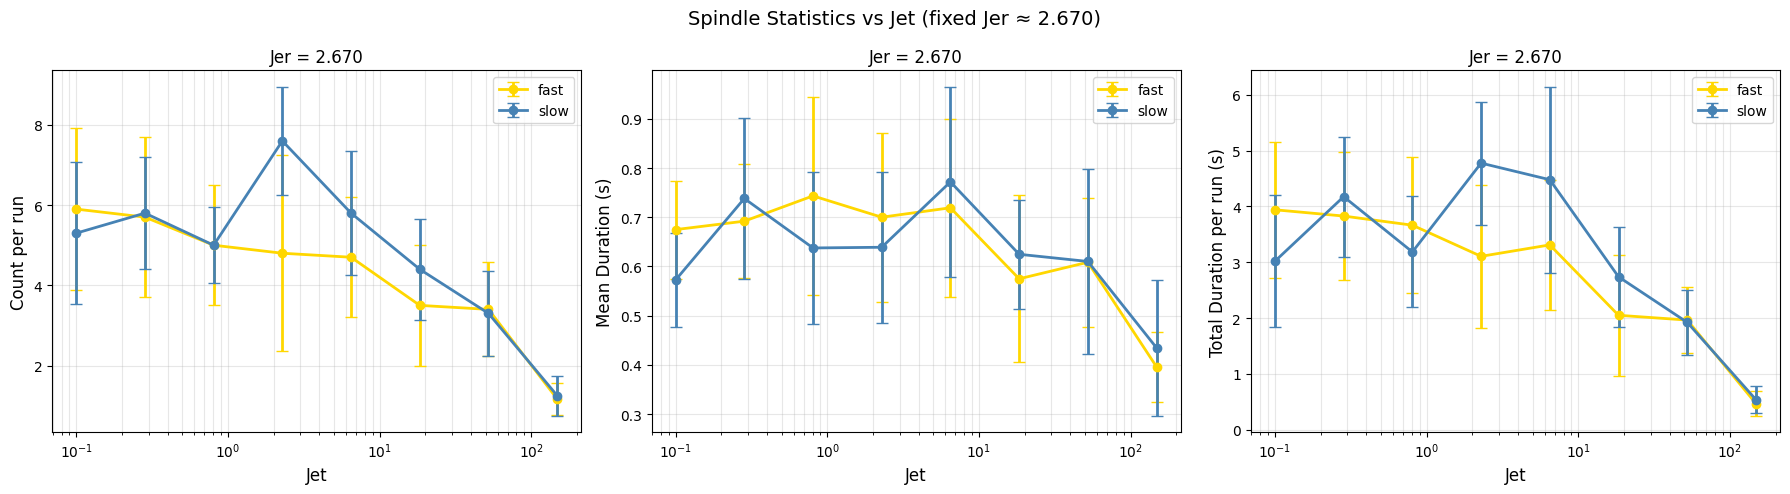

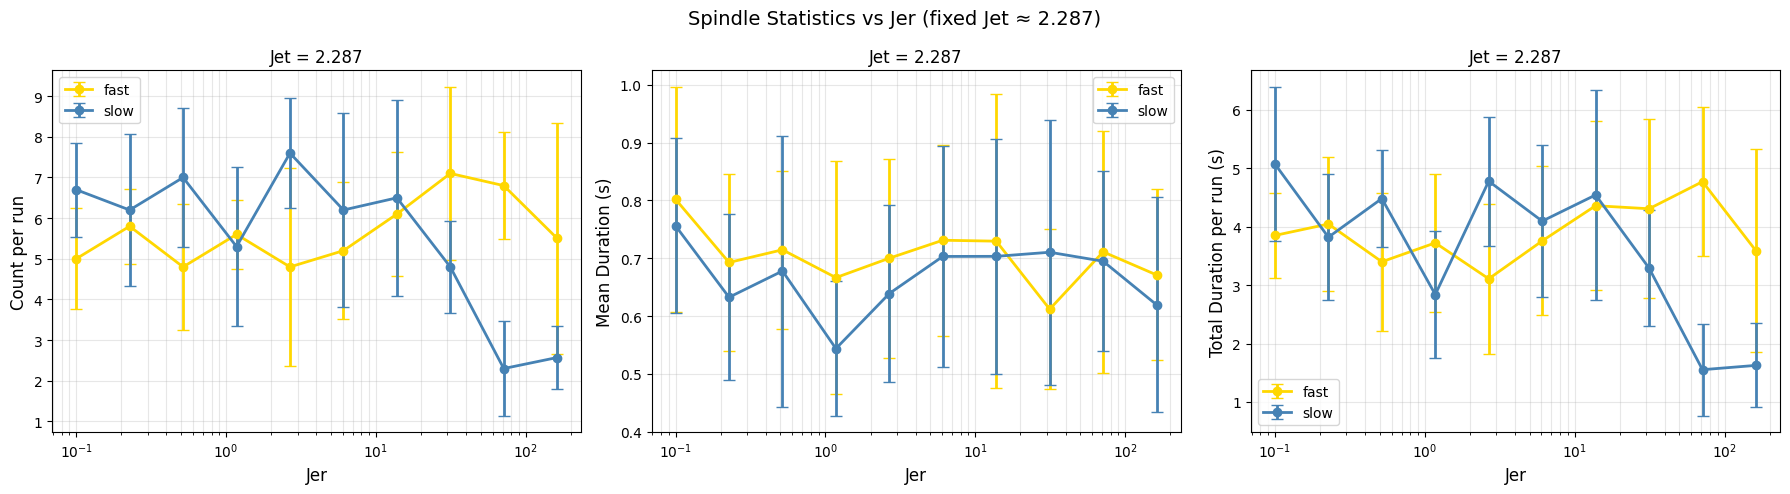

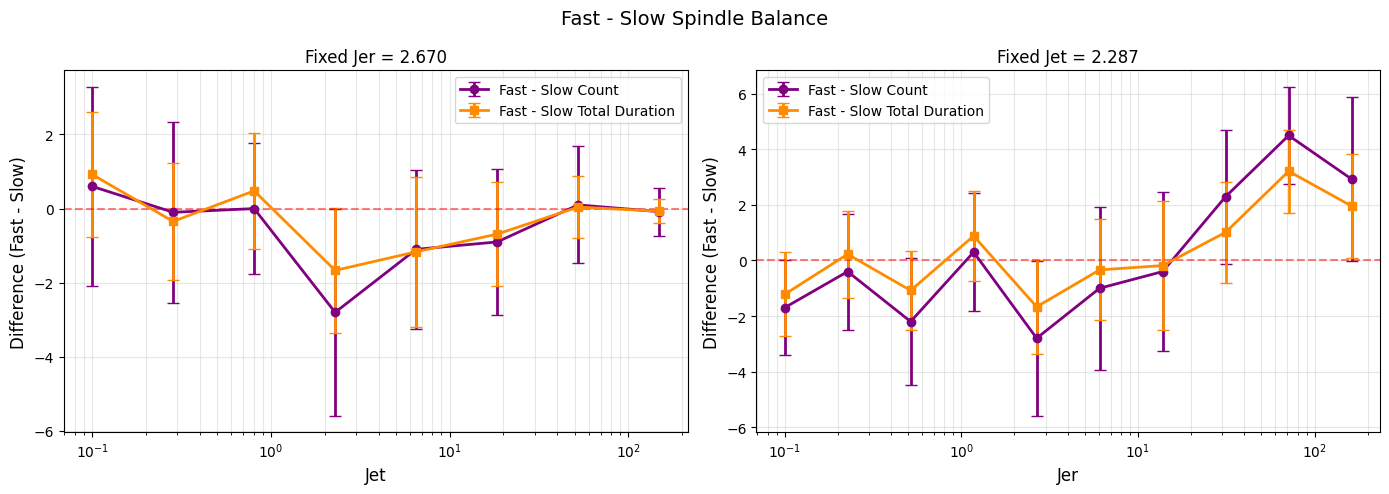


统计摘要

FAST 纺锤波:
  数量最多: Jet=0.1, Jer=13.8, count=7.7
  数量最少: Jet=148.5, Jer=0.2, count=1.0

SLOW 纺锤波:
  数量最多: Jet=2.3, Jer=2.7, count=7.6
  数量最少: Jet=148.5, Jer=0.1, count=1.0


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# ========== 读取数据 ==========
df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_explore_valid_limited.csv")

# ========== 数据筛选 ==========
if 'masked' in df.columns:
    df = df[~df['masked']].copy()

print(f"总纺锤波数: {len(df)}")
print(f"Jet 范围: {df['Jet'].min():.2f} ~ {df['Jet'].max():.2f}")
print(f"Jer 范围: {df['Jer'].min():.2f} ~ {df['Jer'].max():.2f}")

# ========== 按 Jet, Jer, seed, type 分组统计 ==========
seed_stats = df.groupby(['Jet', 'Jer', 'seed', 'type']).agg(
    count=('duration', 'size'),
    mean_duration=('duration', 'mean'),
    total_duration=('duration', 'sum'),
).reset_index()

summary_stats = seed_stats.groupby(['Jet', 'Jer', 'type']).agg(
    mean_count=('count', 'mean'),
    std_count=('count', 'std'),
    mean_duration=('mean_duration', 'mean'),
    std_duration=('mean_duration', 'std'),
    mean_total_duration=('total_duration', 'mean'),
    std_total_duration=('total_duration', 'std'),
).reset_index()

print("\n统计结果列名:")
print(summary_stats.columns.tolist())

# ========== 获取参数值 ==========
Jet_values = sorted(df['Jet'].unique())
Jer_values = sorted(df['Jer'].unique())
print(f"\nJet 采样点: {len(Jet_values)}")
print(f"Jer 采样点: {len(Jer_values)}")

# ========== 选择固定的参数值（接近 2-3 之间）==========
# 固定 Jer 时，选择最接近 2.5 的 Jer 值
target_Jer = 2.5
fixed_Jer = min(Jer_values, key=lambda x: abs(x - target_Jer))
print(f"\n固定的 Jer 值: {fixed_Jer:.4f} (最接近 {target_Jer})")

# 固定 Jet 时，选择最接近 2.5 的 Jet 值
target_Jet = 2.5
fixed_Jet = min(Jet_values, key=lambda x: abs(x - target_Jet))
print(f"固定的 Jet 值: {fixed_Jet:.4f} (最接近 {target_Jet})")

# 颜色（各两条线）
colors_fast_slow = {'fast': 'gold', 'slow': 'steelblue'}

# ========== 图1：固定 Jer，看 Jet 对快慢纺锤波的影响 ==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = [
    ('mean_count', 'Count per run', 'std_count'),
    ('mean_duration', 'Mean Duration (s)', 'std_duration'),
    ('mean_total_duration', 'Total Duration per run (s)', 'std_total_duration')
]

for idx, (metric, ylabel, std_metric) in enumerate(metrics):
    ax = axes[idx]
    for spindle_type in ['fast', 'slow']:
        subset = summary_stats[(summary_stats['type'] == spindle_type) & 
                               (np.abs(summary_stats['Jer'] - fixed_Jer) < 1e-6)]
        if len(subset) > 0:
            subset_sorted = subset.sort_values('Jet')
            ax.errorbar(subset_sorted['Jet'], subset_sorted[metric], 
                       yerr=subset_sorted[std_metric],
                       fmt='o-', capsize=4, color=colors_fast_slow[spindle_type], 
                       label=spindle_type, linewidth=2, markersize=6)
    ax.set_xlabel('Jet', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f'Jer = {fixed_Jer:.3f}', fontsize=12)
    ax.set_xscale('log')
    ax.legend()
    ax.grid(True, alpha=0.3, which='both')

plt.suptitle(f'Spindle Statistics vs Jet (fixed Jer ≈ {fixed_Jer:.3f})', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 图2：固定 Jet，看 Jer 对快慢纺锤波的影响 ==========
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (metric, ylabel, std_metric) in enumerate(metrics):
    ax = axes[idx]
    for spindle_type in ['fast', 'slow']:
        subset = summary_stats[(summary_stats['type'] == spindle_type) & 
                               (np.abs(summary_stats['Jet'] - fixed_Jet) < 1e-6)]
        if len(subset) > 0:
            subset_sorted = subset.sort_values('Jer')
            ax.errorbar(subset_sorted['Jer'], subset_sorted[metric], 
                       yerr=subset_sorted[std_metric],
                       fmt='o-', capsize=4, color=colors_fast_slow[spindle_type], 
                       label=spindle_type, linewidth=2, markersize=6)
    ax.set_xlabel('Jer', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f'Jet = {fixed_Jet:.3f}', fontsize=12)
    ax.set_xscale('log')
    ax.legend()
    ax.grid(True, alpha=0.3, which='both')

plt.suptitle(f'Spindle Statistics vs Jer (fixed Jet ≈ {fixed_Jet:.3f})', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 图3：快慢差值（固定 Jer）==========
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 分离快慢数据
fast_stats = summary_stats[summary_stats['type'] == 'fast'][['Jet', 'Jer', 'mean_count', 'std_count', 'mean_duration', 'std_duration', 'mean_total_duration', 'std_total_duration']]
slow_stats = summary_stats[summary_stats['type'] == 'slow'][['Jet', 'Jer', 'mean_count', 'std_count', 'mean_duration', 'std_duration', 'mean_total_duration', 'std_total_duration']]

# 合并计算差值
diff_stats = pd.merge(fast_stats, slow_stats, on=['Jet', 'Jer'], suffixes=('_fast', '_slow'))
diff_stats['diff_count'] = diff_stats['mean_count_fast'] - diff_stats['mean_count_slow']
diff_stats['diff_count_std'] = np.sqrt(diff_stats['std_count_fast']**2 + diff_stats['std_count_slow']**2)
diff_stats['diff_total'] = diff_stats['mean_total_duration_fast'] - diff_stats['mean_total_duration_slow']
diff_stats['diff_total_std'] = np.sqrt(diff_stats['std_total_duration_fast']**2 + diff_stats['std_total_duration_slow']**2)

# 固定 Jer，看 Jet 对差值的影响
ax = axes[0]
subset = diff_stats[np.abs(diff_stats['Jer'] - fixed_Jer) < 1e-6]
if len(subset) > 0:
    subset_sorted = subset.sort_values('Jet')
    ax.errorbar(subset_sorted['Jet'], subset_sorted['diff_count'], 
               yerr=subset_sorted['diff_count_std'],
               fmt='o-', capsize=4, color='purple', label='Fast - Slow Count', linewidth=2, markersize=6)
    ax.errorbar(subset_sorted['Jet'], subset_sorted['diff_total'], 
               yerr=subset_sorted['diff_total_std'],
               fmt='s-', capsize=4, color='darkorange', label='Fast - Slow Total Duration', linewidth=2, markersize=6)
ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Difference (Fast - Slow)', fontsize=12)
ax.set_title(f'Fixed Jer = {fixed_Jer:.3f}', fontsize=12)
ax.set_xscale('log')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.3, which='both')

# 固定 Jet，看 Jer 对差值的影响
ax = axes[1]
subset = diff_stats[np.abs(diff_stats['Jet'] - fixed_Jet) < 1e-6]
if len(subset) > 0:
    subset_sorted = subset.sort_values('Jer')
    ax.errorbar(subset_sorted['Jer'], subset_sorted['diff_count'], 
               yerr=subset_sorted['diff_count_std'],
               fmt='o-', capsize=4, color='purple', label='Fast - Slow Count', linewidth=2, markersize=6)
    ax.errorbar(subset_sorted['Jer'], subset_sorted['diff_total'], 
               yerr=subset_sorted['diff_total_std'],
               fmt='s-', capsize=4, color='darkorange', label='Fast - Slow Total Duration', linewidth=2, markersize=6)
ax.set_xlabel('Jer', fontsize=12)
ax.set_ylabel('Difference (Fast - Slow)', fontsize=12)
ax.set_title(f'Fixed Jet = {fixed_Jet:.3f}', fontsize=12)
ax.set_xscale('log')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.3, which='both')

plt.suptitle('Fast - Slow Spindle Balance', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 打印统计摘要 ==========
print("\n" + "="*60)
print("统计摘要")
print("="*60)

for spindle_type in ['fast', 'slow']:
    print(f"\n{spindle_type.upper()} 纺锤波:")
    subset = summary_stats[summary_stats['type'] == spindle_type]
    if len(subset) > 0:
        max_count_row = subset.loc[subset['mean_count'].idxmax()]
        min_count_row = subset.loc[subset['mean_count'].idxmin()]
        print(f"  数量最多: Jet={max_count_row['Jet']:.1f}, Jer={max_count_row['Jer']:.1f}, count={max_count_row['mean_count']:.1f}")
        print(f"  数量最少: Jet={min_count_row['Jet']:.1f}, Jer={min_count_row['Jer']:.1f}, count={min_count_row['mean_count']:.1f}")

### PSD

选择的参数组合:
  Jet=6.5, Jer=2.7 (Jet > Jer) (Jet > Jer)
  Jet=2.3, Jer=6.1 (Jer > Jet) (Jer > Jet)
  Jet=0.8, Jer=31.4 (Jer >> Jet) (Jer > Jet)

找到 800 个文件

Jet=6.5, Jer=2.7: 找到 10 个 seed
  seed=1: c2tsc_0.8000_scale2_0.0013_Jet_6.4925_Jer_2.6696_seed_1.npy
  seed=2: c2tsc_0.8000_scale2_0.0013_Jet_6.4925_Jer_2.6696_seed_2.npy
  seed=3: c2tsc_0.8000_scale2_0.0013_Jet_6.4925_Jer_2.6696_seed_3.npy
  seed=4: c2tsc_0.8000_scale2_0.0013_Jet_6.4925_Jer_2.6696_seed_4.npy
  seed=5: c2tsc_0.8000_scale2_0.0013_Jet_6.4925_Jer_2.6696_seed_5.npy
  seed=6: c2tsc_0.8000_scale2_0.0013_Jet_6.4925_Jer_2.6696_seed_6.npy
  seed=7: c2tsc_0.8000_scale2_0.0013_Jet_6.4925_Jer_2.6696_seed_7.npy
  seed=8: c2tsc_0.8000_scale2_0.0013_Jet_6.4925_Jer_2.6696_seed_8.npy
  seed=9: c2tsc_0.8000_scale2_0.0013_Jet_6.4925_Jer_2.6696_seed_9.npy
  seed=10: c2tsc_0.8000_scale2_0.0013_Jet_6.4925_Jer_2.6696_seed_10.npy

Jet=2.3, Jer=6.1: 找到 10 个 seed
  seed=1: c2tsc_0.8000_scale2_0.0013_Jet_2.2872_Jer_6.0683_seed_1.npy
  seed=2: c2

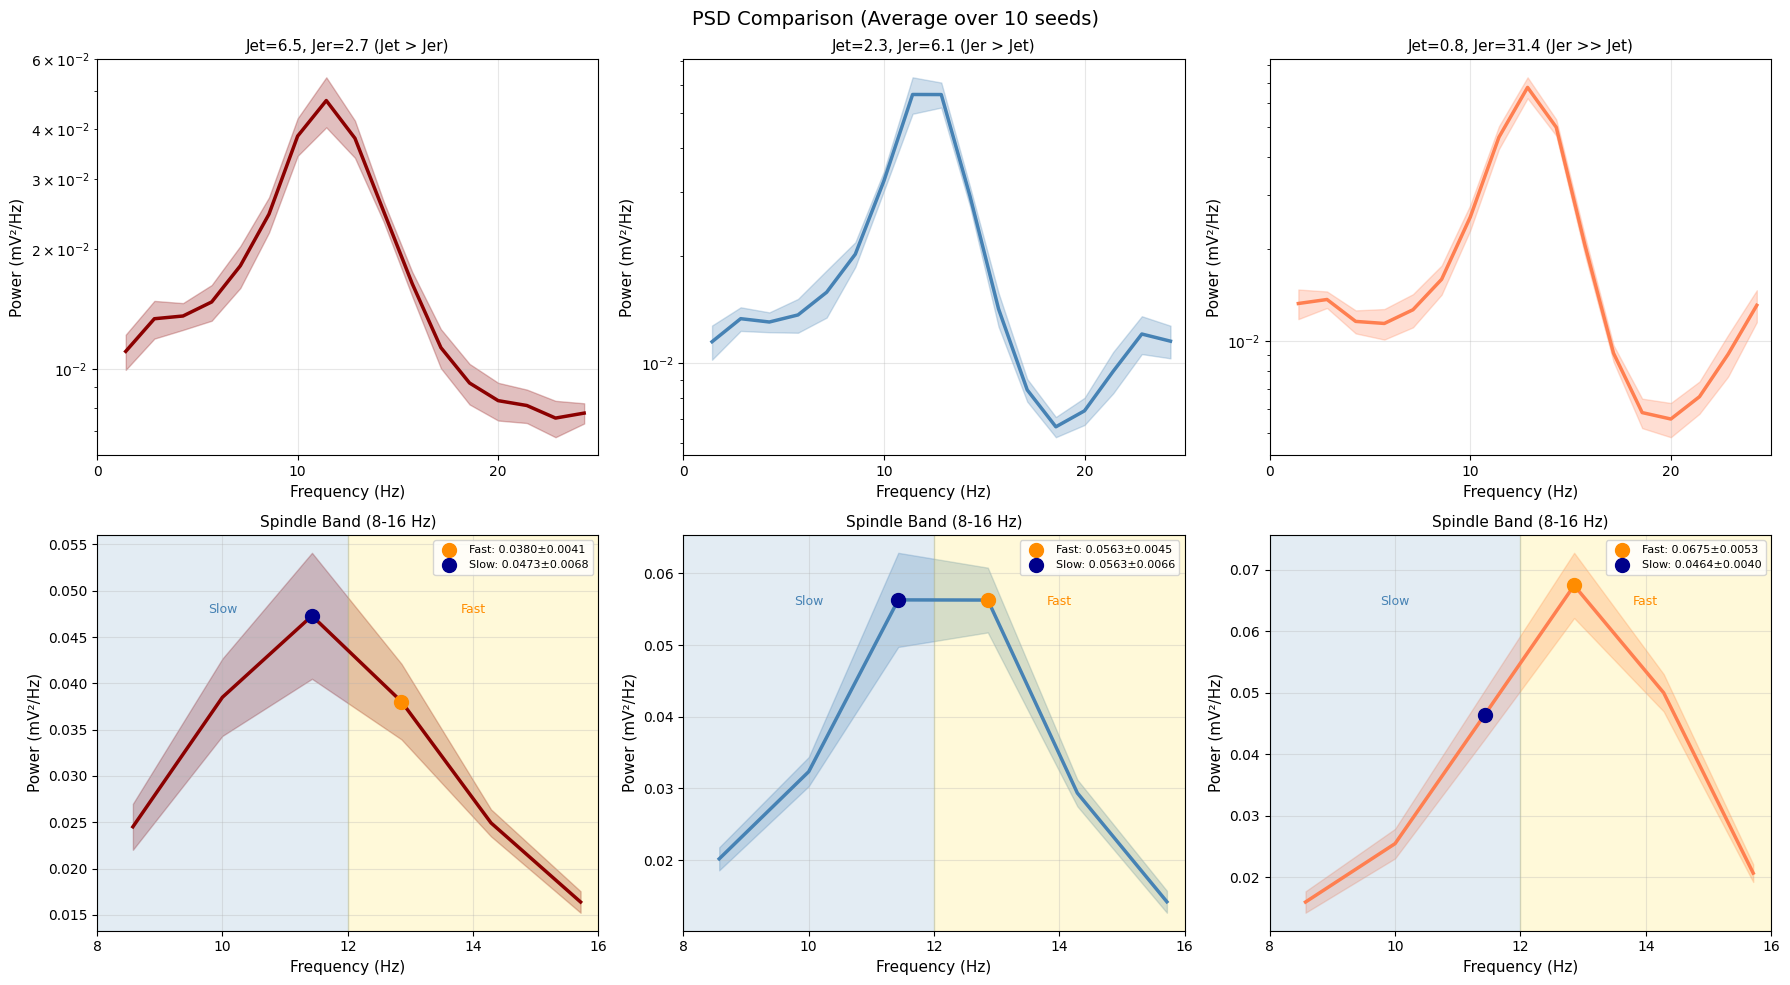


纺锤波功率对比（平均值 ± 标准差，n=10 seeds）

Jet=6.5, Jer=2.7 (Jet > Jer):
  快纺锤波峰值: 0.038026 ± 0.004082 mV²/Hz
  慢纺锤波峰值: 0.047293 ± 0.006801 mV²/Hz
  快/慢比值: 0.804

Jet=2.3, Jer=6.1 (Jer > Jet):
  快纺锤波峰值: 0.056285 ± 0.004516 mV²/Hz
  慢纺锤波峰值: 0.056309 ± 0.006565 mV²/Hz
  快/慢比值: 1.000

Jet=0.8, Jer=31.4 (Jer >> Jet):
  快纺锤波峰值: 0.067471 ± 0.005306 mV²/Hz
  慢纺锤波峰值: 0.046391 ± 0.003965 mV²/Hz
  快/慢比值: 1.454


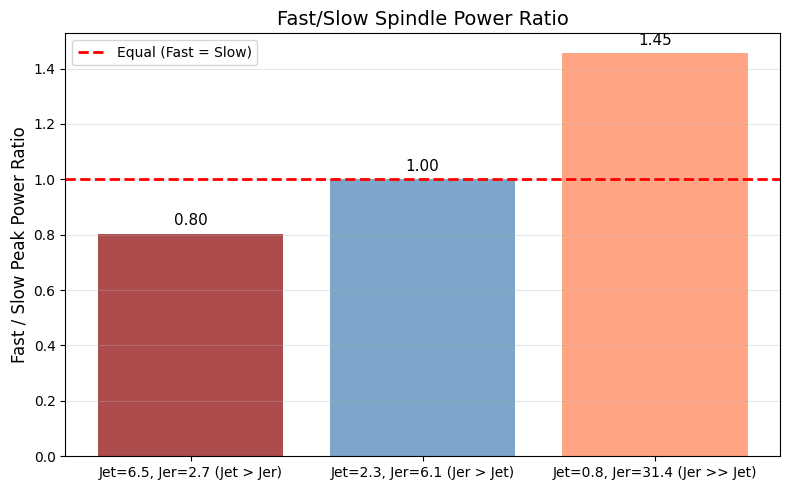

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import glob
import os

# ========== 参数设置 ==========
sf = 10000  # 采样率
raw_data_dir = "data/raw_data_explore_Jet_Jer"

# ========== 选择三组参数（0.8那组放最后）==========
selected_combinations = [
    # (Jet, Jer, color, label)
    (6.4925, 2.6696, 'darkred', 'Jet=6.5, Jer=2.7 (Jet > Jer)'),
    (2.2872, 6.0683, 'steelblue', 'Jet=2.3, Jer=6.1 (Jer > Jet)'),
    (0.8058, 31.3537, 'coral', 'Jet=0.8, Jer=31.4 (Jer >> Jet)'),
]

N_SEEDS = 10

print("选择的参数组合:")
for Jet, Jer, color, label in selected_combinations:
    if Jet > Jer:
        print(f"  {label} (Jet > Jer)")
    else:
        print(f"  {label} (Jer > Jet)")

# ========== 查找匹配的文件 ==========
npy_files = glob.glob(os.path.join(raw_data_dir, "*.npy"))
print(f"\n找到 {len(npy_files)} 个文件")

selected_files = {}

for Jet, Jer, color, label in selected_combinations:
    matched = []
    for f in npy_files:
        filename = os.path.basename(f)
        parts = filename.replace('.npy', '').split('_')
        file_Jet = None
        file_Jer = None
        file_seed = None
        for i, part in enumerate(parts):
            if part == 'Jet' and i+1 < len(parts):
                file_Jet = float(parts[i+1])
            if part == 'Jer' and i+1 < len(parts):
                file_Jer = float(parts[i+1])
            if part == 'seed' and i+1 < len(parts):
                file_seed = int(parts[i+1])
        if file_Jet is not None and file_Jer is not None:
            if abs(file_Jet - Jet) < 0.1 and abs(file_Jer - Jer) < 0.1:
                matched.append((file_seed, f))
    
    matched.sort(key=lambda x: x[0])
    matched = matched[:N_SEEDS]
    selected_files[(Jet, Jer)] = matched
    print(f"\nJet={Jet:.1f}, Jer={Jer:.1f}: 找到 {len(matched)} 个 seed")
    for seed, f in matched:
        print(f"  seed={seed}: {os.path.basename(f)}")

# ========== 计算所有 seed 的 PSD，然后平均 ==========
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_idx, (Jet, Jer, color, label) in enumerate(selected_combinations):
    matched = selected_files.get((Jet, Jer), [])
    if len(matched) == 0:
        continue
    
    all_psd = []
    all_f = None
    
    for seed, file_path in matched:
        data = np.load(file_path, allow_pickle=True).item()
        V_t = data["V_t"]
        f, Pxx = signal.welch(V_t, sf, nperseg=sf*0.7, scaling='density')
        
        if all_f is None:
            all_f = f
        all_psd.append(Pxx)
    
    if len(all_psd) == 0:
        continue
    
    all_psd = np.array(all_psd)
    psd_mean = np.mean(all_psd, axis=0)
    psd_std = np.std(all_psd, axis=0)
    
    # ========== 行1：全频段 PSD ==========
    ax = axes[0, col_idx]
    mask = (all_f >= 0.5) & (all_f <= 25)
    
    ax.semilogy(all_f[mask], psd_mean[mask], linewidth=2.5, color=color)
    ax.fill_between(all_f[mask], 
                     psd_mean[mask] - psd_std[mask], 
                     psd_mean[mask] + psd_std[mask], 
                     color=color, alpha=0.25)
    
    ax.set_xlabel('Frequency (Hz)', fontsize=11)
    ax.set_ylabel('Power (mV²/Hz)', fontsize=11)
    ax.set_title(label, fontsize=11)
    ax.set_xlim(0, 25)
    ax.set_xticks(np.arange(0, 26, 10))
    ax.grid(True, alpha=0.3)
    
    # ========== 行2：纺锤波频段放大（8-16 Hz）==========
    ax = axes[1, col_idx]
    mask_spindle = (all_f >= 8) & (all_f <= 16)
    
    ax.plot(all_f[mask_spindle], psd_mean[mask_spindle], linewidth=2.5, color=color)
    ax.fill_between(all_f[mask_spindle], 
                     psd_mean[mask_spindle] - psd_std[mask_spindle], 
                     psd_mean[mask_spindle] + psd_std[mask_spindle], 
                     color=color, alpha=0.25)
    
    # 标记纺锤波频段
    ax.axvspan(8, 12, alpha=0.15, color='steelblue')
    ax.axvspan(12, 16, alpha=0.15, color='gold')
    ax.text(10, ax.get_ylim()[1]*0.85, 'Slow', ha='center', fontsize=9, color='steelblue')
    ax.text(14, ax.get_ylim()[1]*0.85, 'Fast', ha='center', fontsize=9, color='darkorange')
    
    # 标记快纺锤波峰值
    mask_fast = (all_f >= 12) & (all_f <= 16)
    if np.any(mask_fast):
        idx_fast = np.argmax(psd_mean[mask_fast])
        peak_fast = psd_mean[mask_fast][idx_fast]
        peak_freq_fast = all_f[mask_fast][idx_fast]
        peak_fast_std = psd_std[mask_fast][idx_fast]
        ax.scatter(peak_freq_fast, peak_fast, color='darkorange', s=100, zorder=5,
                   label=f'Fast: {peak_fast:.4f}±{peak_fast_std:.4f}')
    
    # 标记慢纺锤波峰值
    mask_slow = (all_f >= 8) & (all_f <= 12)
    if np.any(mask_slow):
        idx_slow = np.argmax(psd_mean[mask_slow])
        peak_slow = psd_mean[mask_slow][idx_slow]
        peak_freq_slow = all_f[mask_slow][idx_slow]
        peak_slow_std = psd_std[mask_slow][idx_slow]
        ax.scatter(peak_freq_slow, peak_slow, color='darkblue', s=100, zorder=5,
                   label=f'Slow: {peak_slow:.4f}±{peak_slow_std:.4f}')
    
    ax.set_xlabel('Frequency (Hz)', fontsize=11)
    ax.set_ylabel('Power (mV²/Hz)', fontsize=11)
    ax.set_title('Spindle Band (8-16 Hz)', fontsize=11)
    ax.set_xlim(8, 16)
    ax.set_xticks(np.arange(8, 17, 2))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'PSD Comparison (Average over {N_SEEDS} seeds)', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 打印数值对比 ==========
print("\n" + "="*70)
print(f"纺锤波功率对比（平均值 ± 标准差，n={N_SEEDS} seeds）")
print("="*70)

for Jet, Jer, color, label in selected_combinations:
    matched = selected_files.get((Jet, Jer), [])
    if len(matched) == 0:
        continue
    
    fast_peaks = []
    slow_peaks = []
    fast_integrals = []
    slow_integrals = []
    
    for seed, file_path in matched:
        data = np.load(file_path, allow_pickle=True).item()
        V_t = data["V_t"]
        f, Pxx = signal.welch(V_t, sf, nperseg=sf*0.7, scaling='density')
        
        mask_fast = (f >= 12) & (f <= 16)
        if np.any(mask_fast):
            fast_peaks.append(np.max(Pxx[mask_fast]))
            fast_integrals.append(np.trapz(Pxx[mask_fast], f[mask_fast]))
        
        mask_slow = (f >= 8) & (f <= 12)
        if np.any(mask_slow):
            slow_peaks.append(np.max(Pxx[mask_slow]))
            slow_integrals.append(np.trapz(Pxx[mask_slow], f[mask_slow]))
    
    fast_peak_mean = np.mean(fast_peaks)
    fast_peak_std = np.std(fast_peaks)
    slow_peak_mean = np.mean(slow_peaks)
    slow_peak_std = np.std(slow_peaks)
    ratio = fast_peak_mean / slow_peak_mean if slow_peak_mean > 0 else np.nan
    
    print(f"\n{label}:")
    print(f"  快纺锤波峰值: {fast_peak_mean:.6f} ± {fast_peak_std:.6f} mV²/Hz")
    print(f"  慢纺锤波峰值: {slow_peak_mean:.6f} ± {slow_peak_std:.6f} mV²/Hz")
    print(f"  快/慢比值: {ratio:.3f}")

# ========== 快慢比值柱状图 ==========
fig, ax = plt.subplots(figsize=(8, 5))

labels = []
ratios = []
colors = []

for Jet, Jer, color, label in selected_combinations:
    matched = selected_files.get((Jet, Jer), [])
    if len(matched) == 0:
        continue
    
    fast_peaks = []
    slow_peaks = []
    for seed, file_path in matched:
        data = np.load(file_path, allow_pickle=True).item()
        V_t = data["V_t"]
        f, Pxx = signal.welch(V_t, sf, nperseg=sf*0.7, scaling='density')
        
        mask_fast = (f >= 12) & (f <= 16)
        if np.any(mask_fast):
            fast_peaks.append(np.max(Pxx[mask_fast]))
        
        mask_slow = (f >= 8) & (f <= 12)
        if np.any(mask_slow):
            slow_peaks.append(np.max(Pxx[mask_slow]))
    
    fast_mean = np.mean(fast_peaks)
    slow_mean = np.mean(slow_peaks)
    ratio = fast_mean / slow_mean if slow_mean > 0 else np.nan
    
    labels.append(label)
    ratios.append(ratio)
    colors.append(color)

bars = ax.bar(labels, ratios, color=colors, alpha=0.7)
ax.axhline(y=1, color='red', linestyle='--', linewidth=2, label='Equal (Fast = Slow)')
ax.set_ylabel('Fast / Slow Peak Power Ratio', fontsize=12)
ax.set_title('Fast/Slow Spindle Power Ratio', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bar, ratio in zip(bars, ratios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{ratio:.2f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

总纺锤波数: 6907
Jet 范围: 0.10 ~ 148.50
Jer 范围: 0.10 ~ 162.00

使用的 Jet 值: [0.1, 0.2839, 0.8058, 2.2872, 6.4925, 18.4297, 52.3146]
使用的 Jer 值: [0.1, 0.2273, 0.5167, 1.1745, 2.6696, 6.0683, 13.7936, 31.3537, 71.2693]

原始有效参数组合数: 70
过滤后有效参数组合数: 63


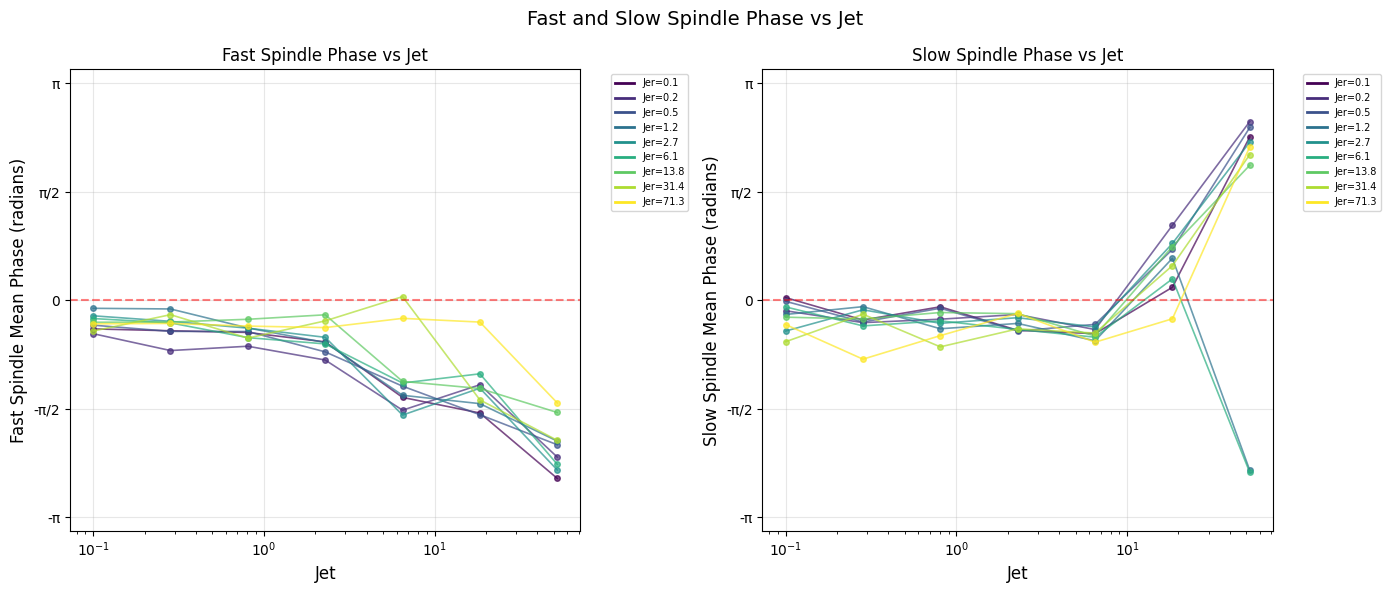

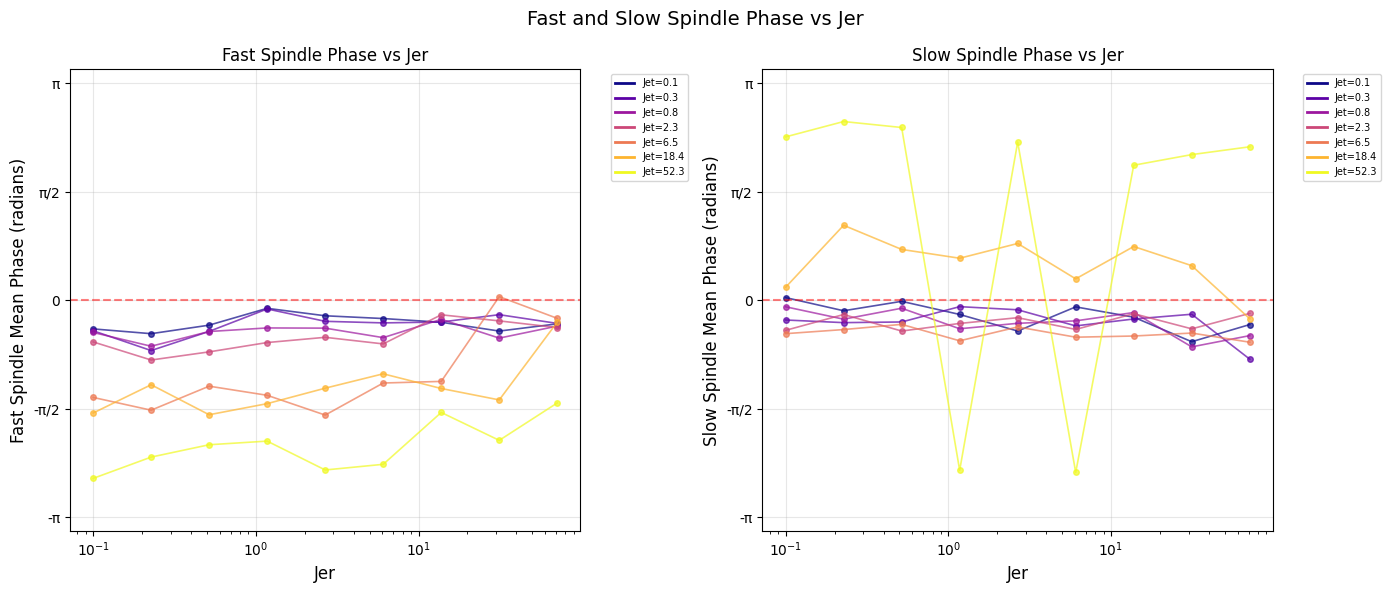

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd, pearsonr

# ========== 读取数据 ==========
df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_explore_valid_limited.csv")

# ========== 数据筛选 ==========
if 'masked' in df.columns:
    df = df[~df['masked']].copy()

print(f"总纺锤波数: {len(df)}")
print(f"Jet 范围: {df['Jet'].min():.2f} ~ {df['Jet'].max():.2f}")
print(f"Jer 范围: {df['Jer'].min():.2f} ~ {df['Jer'].max():.2f}")

# ========== 圆形统计函数 ==========
def circular_stats(phases):
    if len(phases) == 0:
        return np.nan, np.nan
    mean_phase = circmean(phases, low=-np.pi, high=np.pi)
    std_phase = circstd(phases, low=-np.pi, high=np.pi)
    return mean_phase, std_phase

# ========== 获取所有 Jet 和 Jer 值 ==========
Jet_values_all = sorted(df['Jet'].unique())
Jer_values_all = sorted(df['Jer'].unique())

# 去掉你不想显示的值（修改这里即可）
Jet_values_all = Jet_values_all[:-1]  # 去掉最后一个（最大值）
Jer_values_all = Jer_values_all[:-1]  # 去掉最后一个（最大值）

print(f"\n使用的 Jet 值: {Jet_values_all}")
print(f"使用的 Jer 值: {Jer_values_all}")

# ========== 计算每个 (Jet, Jer) 组合下快慢纺锤波的相位 ==========
fast_phase = df[df['type'] == 'fast'].groupby(['Jet', 'Jer'])['phase_at_peak'].apply(
    lambda x: circmean(x.dropna(), low=-np.pi, high=np.pi) if len(x.dropna()) > 5 else np.nan
).reset_index(name='fast_phase')

slow_phase = df[df['type'] == 'slow'].groupby(['Jet', 'Jer'])['phase_at_peak'].apply(
    lambda x: circmean(x.dropna(), low=-np.pi, high=np.pi) if len(x.dropna()) > 5 else np.nan
).reset_index(name='slow_phase')

fast_std = df[df['type'] == 'fast'].groupby(['Jet', 'Jer'])['phase_at_peak'].apply(
    lambda x: circstd(x.dropna(), low=-np.pi, high=np.pi) if len(x.dropna()) > 5 else np.nan
).reset_index(name='fast_std')

slow_std = df[df['type'] == 'slow'].groupby(['Jet', 'Jer'])['phase_at_peak'].apply(
    lambda x: circstd(x.dropna(), low=-np.pi, high=np.pi) if len(x.dropna()) > 5 else np.nan
).reset_index(name='slow_std')

# 合并
phase_df = pd.merge(fast_phase, slow_phase, on=['Jet', 'Jer'])
phase_df = pd.merge(phase_df, fast_std, on=['Jet', 'Jer'])
phase_df = pd.merge(phase_df, slow_std, on=['Jet', 'Jer'])
phase_df['phase_diff'] = phase_df['fast_phase'] - phase_df['slow_phase']
phase_df = phase_df.dropna()

# ========== 关键：用 Jet_values_all 和 Jer_values_all 过滤 phase_df ==========
phase_df_filtered = phase_df[
    (phase_df['Jet'].isin(Jet_values_all)) & 
    (phase_df['Jer'].isin(Jer_values_all))
].copy()

print(f"\n原始有效参数组合数: {len(phase_df)}")
print(f"过滤后有效参数组合数: {len(phase_df_filtered)}")

# ========== 图2：快慢纺锤波各自的相位 vs Jet ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(Jer_values_all)))

# 左图：快纺锤波相位 vs Jet
ax = axes[0]
for i, Jer_val in enumerate(Jer_values_all):
    subset = phase_df_filtered[np.abs(phase_df_filtered['Jer'] - Jer_val) < 1e-6]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jet')
        ax.plot(subset_sorted['Jet'], subset_sorted['fast_phase'], 
                'o-', color=colors[i], alpha=0.7, linewidth=1.2, markersize=4)
ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Fast Spindle Mean Phase (radians)', fontsize=12)
ax.set_title('Fast Spindle Phase vs Jet', fontsize=12)
ax.set_xscale('log')
ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=colors[i], lw=2, label=f'Jer={Jer_values_all[i]:.1f}') 
                   for i in range(0, len(Jer_values_all), max(1, len(Jer_values_all)//5))]
ax.legend(handles=legend_elements, fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# 右图：慢纺锤波相位 vs Jet
ax = axes[1]
for i, Jer_val in enumerate(Jer_values_all):
    subset = phase_df_filtered[np.abs(phase_df_filtered['Jer'] - Jer_val) < 1e-6]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jet')
        ax.plot(subset_sorted['Jet'], subset_sorted['slow_phase'], 
                'o-', color=colors[i], alpha=0.7, linewidth=1.2, markersize=4)
ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Slow Spindle Mean Phase (radians)', fontsize=12)
ax.set_title('Slow Spindle Phase vs Jet', fontsize=12)
ax.set_xscale('log')
ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.legend(handles=legend_elements, fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.suptitle('Fast and Slow Spindle Phase vs Jet', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 图3：快慢纺锤波各自的相位 vs Jer ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors2 = plt.cm.plasma(np.linspace(0, 1, len(Jet_values_all)))

# 左图：快纺锤波相位 vs Jer
ax = axes[0]
for i, Jet_val in enumerate(Jet_values_all):
    subset = phase_df_filtered[np.abs(phase_df_filtered['Jet'] - Jet_val) < 1e-6]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jer')
        ax.plot(subset_sorted['Jer'], subset_sorted['fast_phase'], 
                'o-', color=colors2[i], alpha=0.7, linewidth=1.2, markersize=4)
ax.set_xlabel('Jer', fontsize=12)
ax.set_ylabel('Fast Spindle Mean Phase (radians)', fontsize=12)
ax.set_title('Fast Spindle Phase vs Jer', fontsize=12)
ax.set_xscale('log')
ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)

legend_elements2 = [Line2D([0], [0], color=colors2[i], lw=2, label=f'Jet={Jet_values_all[i]:.1f}') 
                    for i in range(0, len(Jet_values_all), max(1, len(Jet_values_all)//5))]
ax.legend(handles=legend_elements2, fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# 右图：慢纺锤波相位 vs Jer
ax = axes[1]
for i, Jet_val in enumerate(Jet_values_all):
    subset = phase_df_filtered[np.abs(phase_df_filtered['Jet'] - Jet_val) < 1e-6]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jer')
        ax.plot(subset_sorted['Jer'], subset_sorted['slow_phase'], 
                'o-', color=colors2[i], alpha=0.7, linewidth=1.2, markersize=4)
ax.set_xlabel('Jer', fontsize=12)
ax.set_ylabel('Slow Spindle Mean Phase (radians)', fontsize=12)
ax.set_title('Slow Spindle Phase vs Jer', fontsize=12)
ax.set_xscale('log')
ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.legend(handles=legend_elements2, fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.suptitle('Fast and Slow Spindle Phase vs Jer', fontsize=14)
plt.tight_layout()
plt.show()